In [12]:
! pip install triton


In [13]:
!pip install torch


In [14]:
import torch
torch.cuda.is_available()

True

In [15]:
! nvidia-smi

Tue Sep  1 12:01:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             33W /   70W |     123MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
import triton
import triton.language as tl

#device setup

DEVICE = triton.runtime.driver.active.get_active_torch_device()
print(DEVICE)

# the basic task is to add two vectors using a custom triton kernel

@triton.jit()
def add_kernel(
    x_ptr,
    y_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr # constexpr is a marker that says this value must be known when the code is compiled, not when it runs.
):

  pid = tl.program_id(axis=0) # if grid is 4 it is just 0,1,2,3

  block_start = pid * BLOCK_SIZE # for 0:0, 1:BLOCK_SIZE, 2:2*BLOCK_SIZE

  offsets = block_start + tl.arange(0, BLOCK_SIZE)

  mask = offsets < n_elements#guard that keeps the last program from reading and writing off the end of the buffer.

  x = tl.load(x_ptr + offsets, mask=mask) #load from vram to gpu
  y = tl.load(y_ptr+offsets, mask=mask)

  output = x+y #compute in gpu

  tl.store(output_ptr + offsets, output, mask=mask)









cuda:0


In [19]:
#helper function for allocating the output tensor and for enquing the kernel because we are pushing the work onto a cuda stream and the control returns to python immediately and gpu executes later

def add(x: torch.Tensor, y: torch.Tensor):

  output = torch.empty_like(x) # allocate output buffer: same shape/dtype/device as x, contents uninitialized so what value is in x is in output
  assert x.device == DEVICE and y.device == DEVICE and output.device == DEVICE

  n_elements = output.numel() #just the number of elements in the tensor

  # grid is basically how many copies of kernel should be run in parallel
  grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)

  #also can be written as
  # def grid(meta):
  #   return triton.cdiv(n_elements, meta['BLOCK_SIZE'])

  add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=1024) #writes the value in memory in output which was allocated so we don't need to do output =

  return output







In [22]:

torch.manual_seed(100)
vector_size = 123456

x = torch.rand(vector_size, device=DEVICE ) #stored in vram or DRAM
y = torch.rand(vector_size, device=DEVICE)


x_cpu= torch.rand(vector_size, device='cpu' ) #stored in ram
y_cpu = torch.rand(vector_size, device='cpu')

#cpu addition
output_cpu = x_cpu+y_cpu
print(output_cpu)


#normal addition

output_torch = x+y
print(output_torch)

#using triton

output_triton = add(x, y)
print(output_triton)


print(f'The difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')



tensor([0.9969, 1.4748, 0.8443,  ..., 0.6422, 0.3211, 1.2094])
tensor([1.1907, 0.7304, 1.2449,  ..., 0.8801, 1.2362, 0.4522], device='cuda:0')
tensor([1.1907, 0.7304, 1.2449,  ..., 0.8801, 1.2362, 0.4522], device='cuda:0')
The difference between torch and triton is 0.0


In [24]:
# Time grows with the size of the data, so it can only compare implementations at a fixed size. GB/s normalizes by data size, so it stays flat across the sweep which makes it comparable both between implementations and against the card's peak bandwidth.
import time

#cpu
start = time.perf_counter()
for _ in range(100):
    output_cpu = x_cpu + y_cpu
cpu_ms = (time.perf_counter() - start) * 1000 / 100

# gpu in triton and torch
torch_ms  = triton.testing.do_bench(lambda: x + y)
triton_ms = triton.testing.do_bench(lambda: add(x, y))

print(f"CPU torch:    {cpu_ms:.4f} ms")
print(f"GPU torch:    {torch_ms:.4f} ms")
print(f"GPU triton:   {triton_ms:.4f} ms")

CPU torch:    0.0885 ms
GPU torch:    0.0125 ms
GPU triton:   0.0120 ms


In [36]:
# this is a boilerplate code not written by me
# Benchmark: memory bandwidth (GB/s) of z = x + y across tensor sizes,
# comparing our Triton kernel against torch on GPU and triton(self written) on GPU.




@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

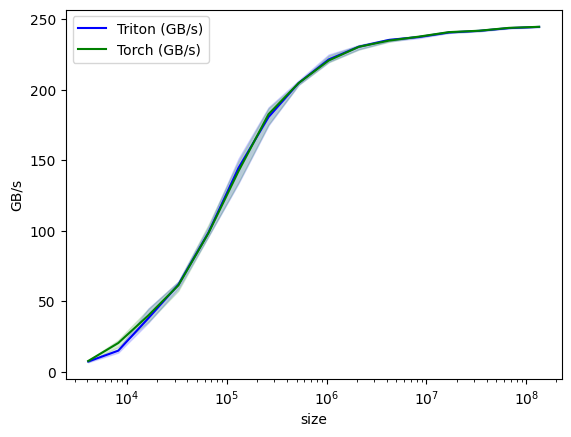

vector-add-performance:
           size  Triton (GB/s)  Torch (GB/s)
0        4096.0       7.211267      7.603961
1        8192.0      14.912622     20.344371
2       16384.0      37.925927     39.896105
3       32768.0      61.748743     61.286783
4       65536.0      98.698793     98.303995
5      131072.0     144.564706    142.263388
6      262144.0     180.705879    182.721182
7      524288.0     204.800005    204.800005
8     1048576.0     221.530139    220.783822
9     2097152.0     230.557615    230.490042
10    4194304.0     235.388203    234.896049
11    8388608.0     237.449270    237.718424
12   16777216.0     240.673884    240.941181
13   33554432.0     241.830252    241.927891
14   67108864.0     243.792278    243.964808
15  134217728.0     244.647266    244.704948


In [33]:

benchmark.run(print_data=True, show_plots=True)


In [34]:
# this is a boilerplate code not written by me
# Benchmark: memory bandwidth (GB/s) of z = x + y across tensor sizes,
# comparing our Triton kernel against torch on GPU,  triton(self written) on GPU and in CPU .


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],
        x_vals=[2**i for i in range(12, 28, 1)],
        x_log=True,
        y_log=True,
        line_arg='provider',
        line_vals=['triton', 'torch', 'cpu'],
        line_names=['Triton (GPU)', 'Torch (GPU)', 'Torch (CPU)'],
        styles=[('blue', '-'), ('green', '-'), ('red', '-')],
        ylabel='GB/s',
        plot_name='vector-add-performance',
        args={},
    ))
def benchmark(size, provider):
    quantiles = [0.5, 0.2, 0.8]

    if provider == 'cpu':
        x = torch.rand(size, device='cpu', dtype=torch.float32)
        y = torch.rand(size, device='cpu', dtype=torch.float32)
    else:
        x = torch.rand(size, device=DEVICE, dtype=torch.float32)
        y = torch.rand(size, device=DEVICE, dtype=torch.float32)

    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    if provider == 'cpu':
        import time
        for _ in range(3):                  # warmup
            x + y
        n = 20
        t0 = time.perf_counter()
        for _ in range(n):
            x + y
        ms = (time.perf_counter() - t0) * 1000 / n
        min_ms = max_ms = ms

    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)

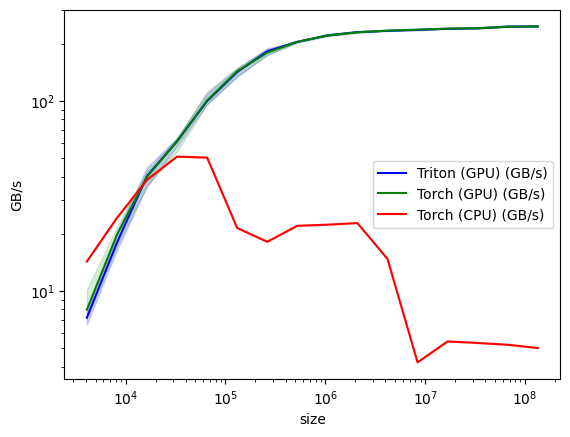

vector-add-performance:
           size  Triton (GPU) (GB/s)  Torch (GPU) (GB/s)  Torch (CPU) (GB/s)
0        4096.0             7.245283            7.979221           14.316464
1        8192.0            17.964912           19.755627           24.252831
2       16384.0            40.288525           39.896105           38.465737
3       32768.0            61.440002           61.286783           50.985568
4       65536.0            99.902441          100.721313           50.380174
5      131072.0           142.057809          143.300295           21.465396
6      262144.0           182.721182          179.714817           18.169834
7      524288.0           204.800005          204.800005           22.047771
8     1048576.0           221.280807          221.032035           22.358041
9     2097152.0           230.490042          229.883662           22.787627
10    4194304.0           234.057145          234.580758           14.752336
11    8388608.0           236.663261          237.44

In [35]:

benchmark.run(print_data=True, show_plots=True)


In [ ]:
# Results:
# - Triton and Torch GPU are identical -> our kernel matches hand-tuned CUDA.
# - Both flatten at ~247 GB/s = the memory bus maxed out; can't go faster.
# - Small sizes are slow for everyone: launch overhead > actual work.
#   Below ~16K elements the CPU actually wins.
# - CPU rises to 51 then crashes to 5 GB/s: small tensors fit in cache
#   (fake speed), big ones show real RAM bandwidth.
# - ~50x GPU win at scale, purely from higher memory bandwidth. The addition
#   itself was never the bottleneck.